# Analyzing Customer Behavior for E-Commerce Insights

## Table of Contents
1. [Environment Setup & Synthetic Data Generation](#1)
2. [Exploratory Data Analysis (EDA)](#2)
3. [Data Cleaning](#3)
4. [Feature Engineering](#4)
5. [Apache Spark – Big Data Processing](#5)
6. [Predictive Modeling – Customer Churn](#6)
7. [Insights and Visualizations](#7)
8. [Business Recommendations](#8)

## INSTALLATION OF REQUIRED LIBRARIES


In [2]:
# Install necessary libraries for the e-commerce analysis
%pip install pandas numpy matplotlib seaborn Faker scikit-learn pyspark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 26.9 MB/s eta 0:00:00


## 1. Environment Setup & Synthetic Data Generation

In [3]:
# Library Imports
# All standard data-science libraries and Apache Spark for big-data processing.
import warnings
warnings.filterwarnings('ignore')

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Synthetic data generation
from faker import Faker
import random
from datetime import datetime, timedelta

# Machine learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Apache Spark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler, StandardScaler as SparkScaler
from pyspark.ml.classification import RandomForestClassifier as SparkRF
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Plot theme
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('All libraries imported successfully.')

All libraries imported successfully.


In [4]:
# Synthetic Dataset Generation
# We generate 50,000 rows simulating one year of e-commerce activity.
# Three logical tables:
#   customers  – demographics
#   sessions   – browsing behaviour per visit
#   orders     – purchase history

fake = Faker()
Faker.seed(SEED)

N_CUSTOMERS  = 5_000
N_SESSIONS   = 50_000
START_DATE   = datetime(2023, 1, 1)
END_DATE     = datetime(2023, 12, 31)

CATEGORIES   = ['Electronics', 'Fashion', 'Home & Garden', 'Books',
                 'Sports', 'Beauty', 'Toys', 'Grocery']
DEVICES      = ['mobile', 'desktop', 'tablet']
GENDERS      = ['Male', 'Female', 'Non-binary']
REGIONS      = ['North', 'South', 'East', 'West', 'Central']

def rand_date(start, end):
    delta = int((end - start).total_seconds())
    return start + timedelta(seconds=random.randint(0, delta))

# Customers
customer_ids = [f'C{str(i).zfill(5)}' for i in range(1, N_CUSTOMERS + 1)]
customers_df = pd.DataFrame({
    'customer_id'     : customer_ids,
    'age'             : np.random.randint(18, 70, N_CUSTOMERS),
    'gender'          : np.random.choice(GENDERS, N_CUSTOMERS, p=[0.48, 0.48, 0.04]),
    'region'          : np.random.choice(REGIONS, N_CUSTOMERS),
    'membership_days' : np.random.randint(1, 1096, N_CUSTOMERS),
    'loyalty_score'   : np.random.uniform(0, 100, N_CUSTOMERS).round(1),
})

# Sessions / Browsing Behaviour
sessions_df = pd.DataFrame({
    'session_id'       : [f'S{str(i).zfill(6)}' for i in range(1, N_SESSIONS + 1)],
    'customer_id'      : np.random.choice(customer_ids, N_SESSIONS),
    'session_date'     : [rand_date(START_DATE, END_DATE) for _ in range(N_SESSIONS)],
    'device'           : np.random.choice(DEVICES, N_SESSIONS, p=[0.55, 0.35, 0.10]),
    'category_viewed'  : np.random.choice(CATEGORIES, N_SESSIONS),
    'pages_viewed'     : np.random.randint(1, 30, N_SESSIONS),
    'session_duration' : np.random.exponential(scale=8, size=N_SESSIONS).clip(1, 60).round(1),
    'items_added_cart' : np.random.poisson(1.2, N_SESSIONS),
    'converted'        : np.random.choice([0, 1], N_SESSIONS, p=[0.72, 0.28]),
})

# Orders
converted_sessions = sessions_df[sessions_df['converted'] == 1].copy()
orders_df = pd.DataFrame({
    'order_id'         : [f'O{str(i).zfill(6)}' for i in range(1, len(converted_sessions) + 1)],
    'session_id'       : converted_sessions['session_id'].values,
    'customer_id'      : converted_sessions['customer_id'].values,
    'order_date'       : converted_sessions['session_date'].values,
    'product_category' : converted_sessions['category_viewed'].values,
    'order_value'      : np.random.lognormal(mean=3.8, sigma=0.9, size=len(converted_sessions)).round(2),
    'items_purchased'  : np.random.randint(1, 8, len(converted_sessions)),
    'discount_applied' : np.random.choice([0, 1], len(converted_sessions), p=[0.60, 0.40]),
    'return_flag'      : np.random.choice([0, 1], len(converted_sessions), p=[0.88, 0.12]),
})

# Introduce realistic noise: missing values and duplicates
customers_df.loc[customers_df.sample(frac=0.03, random_state=SEED).index, 'age'] = np.nan
customers_df.loc[customers_df.sample(frac=0.02, random_state=SEED).index, 'loyalty_score'] = np.nan
sessions_df.loc[sessions_df.sample(frac=0.01, random_state=SEED).index, 'device'] = np.nan
dup_rows = sessions_df.sample(frac=0.005, random_state=SEED)
sessions_df = pd.concat([sessions_df, dup_rows], ignore_index=True)

print(f'Customers : {len(customers_df):,}')
print(f'Sessions  : {len(sessions_df):,}')
print(f'Orders    : {len(orders_df):,}')

Customers : 5,000
Sessions  : 50,250
Orders    : 13,970


## 2. Exploratory Data Analysis

In [5]:
# Dataset Structure Overview
print('=' * 60)
print('CUSTOMERS TABLE')
print('=' * 60)
print(customers_df.info())
display(customers_df.describe(include='all').T)

print('\n' + '=' * 60)
print('SESSIONS TABLE')
print('=' * 60)
print(sessions_df.info())
display(sessions_df.describe(include='all').T)

print('\n' + '=' * 60)
print('ORDERS TABLE')
print('=' * 60)
print(orders_df.info())
display(orders_df.describe().T)

CUSTOMERS TABLE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      5000 non-null   object 
 1   age              4850 non-null   float64
 2   gender           5000 non-null   object 
 3   region           5000 non-null   object 
 4   membership_days  5000 non-null   int64  
 5   loyalty_score    4900 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 234.5+ KB
None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,5000,5000,C05000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,4850.0,NaN,NaN,NaN,43.619175,14.9504,18.0,31.0,43.0,56.0,69.0
gender,5000,3,Male,2456,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,5000,5,West,1040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
membership_days,5000.0,NaN,NaN,NaN,552.0302,317.969965,1.0,273.0,561.0,826.0,1095.0
loyalty_score,4900.0,NaN,NaN,NaN,50.954184,28.919322,0.1,26.5,51.4,75.5,100.0



SESSIONS TABLE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50250 entries, 0 to 50249
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   session_id        50250 non-null  object        
 1   customer_id       50250 non-null  object        
 2   session_date      50250 non-null  datetime64[ns]
 3   device            49500 non-null  object        
 4   category_viewed   50250 non-null  object        
 5   pages_viewed      50250 non-null  int64         
 6   session_duration  50250 non-null  float64       
 7   items_added_cart  50250 non-null  int64         
 8   converted         50250 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 3.5+ MB
None


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
session_id,50250,50000,S038243,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,50250,5000,C02223,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_date,50250,NaN,NaN,NaN,2023-07-01 18:35:47.479502592,2023-01-01 00:05:18,2023-04-01 11:36:12.249999872,2023-07-01 13:33:05.500000,2023-09-30 08:50:40.500000,2023-12-30 23:43:32,NaN
device,49500,3,mobile,27246,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_viewed,50250,8,Grocery,6351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pages_viewed,50250.0,NaN,NaN,NaN,14.997075,1.0,8.0,15.0,22.0,29.0,8.346141
session_duration,50250.0,NaN,NaN,NaN,8.041351,1.0,2.3,5.5,11.0,60.0,7.887252
items_added_cart,50250.0,NaN,NaN,NaN,1.201831,0.0,0.0,1.0,2.0,7.0,1.095356
converted,50250.0,NaN,NaN,NaN,0.279323,0.0,0.0,0.0,1.0,1.0,0.448671



ORDERS TABLE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13970 entries, 0 to 13969
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          13970 non-null  object        
 1   session_id        13970 non-null  object        
 2   customer_id       13970 non-null  object        
 3   order_date        13970 non-null  datetime64[ns]
 4   product_category  13970 non-null  object        
 5   order_value       13970 non-null  float64       
 6   items_purchased   13970 non-null  int64         
 7   discount_applied  13970 non-null  int64         
 8   return_flag       13970 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 982.4+ KB
None


,count,mean,min,25%,50%,75%,max,std
order_date,13970,2023-07-02 15:36:54.052899072,2023-01-01 00:19:58,2023-04-03 02:58:37.750000128,2023-07-03 07:03:01,2023-10-01 10:14:28.750000128,2023-12-30 23:33:35,NaN
order_value,13970.0,66.813079,1.22,24.46,44.185,80.9175,1088.8,74.357026
items_purchased,13970.0,3.991482,1.0,2.0,4.0,6.0,7.0,1.998173
discount_applied,13970.0,0.402935,0.0,0.0,0.0,1.0,1.0,0.490505
return_flag,13970.0,0.118253,0.0,0.0,0.0,0.0,1.0,0.322919


Customers duplicates: 0
Sessions duplicates: 250
Orders duplicates: 0


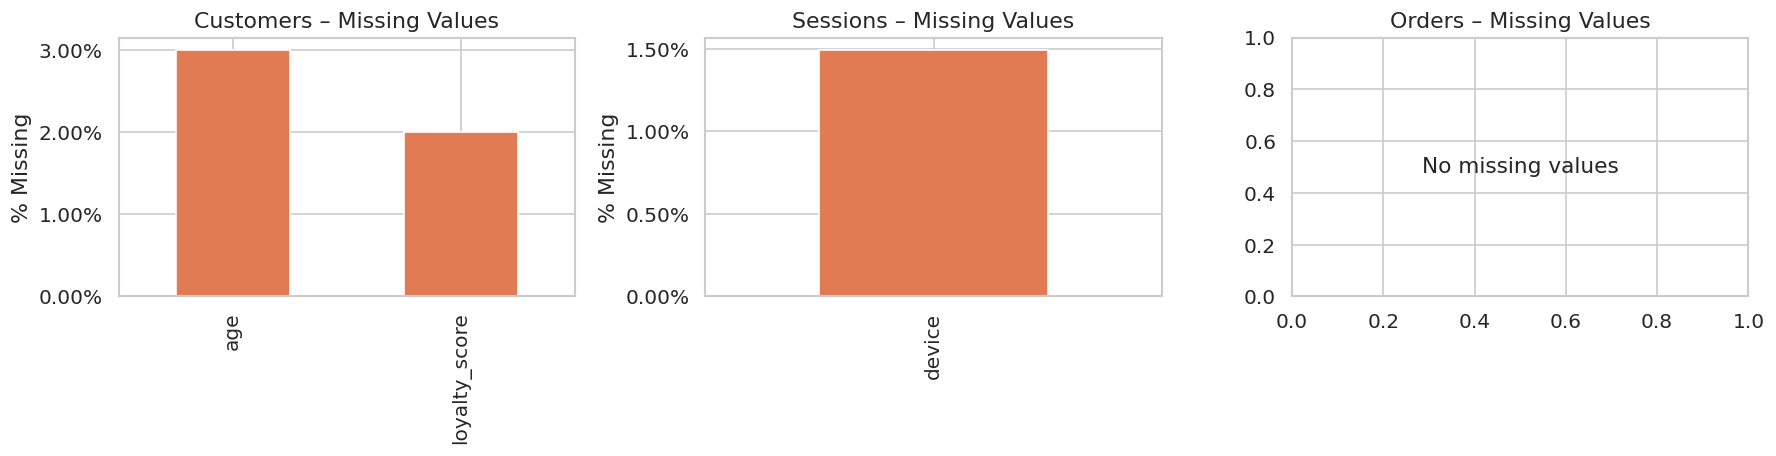

In [6]:
# Missing Values and Duplicates Audit
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (df, title) in zip(axes, [
    (customers_df, 'Customers'),
    (sessions_df,  'Sessions'),
    (orders_df,    'Orders')
]):
    miss = df.isnull().mean() * 100
    miss = miss[miss > 0]
    if miss.empty:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center',
                fontsize=13, transform=ax.transAxes)
    else:
        miss.plot(kind='bar', ax=ax, color='#e07b54', edgecolor='white')
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set_ylabel('% Missing')
    ax.set_title(f'{title} – Missing Values')
    print(f'{title} duplicates: {df.duplicated().sum()}')

plt.tight_layout()
plt.show()

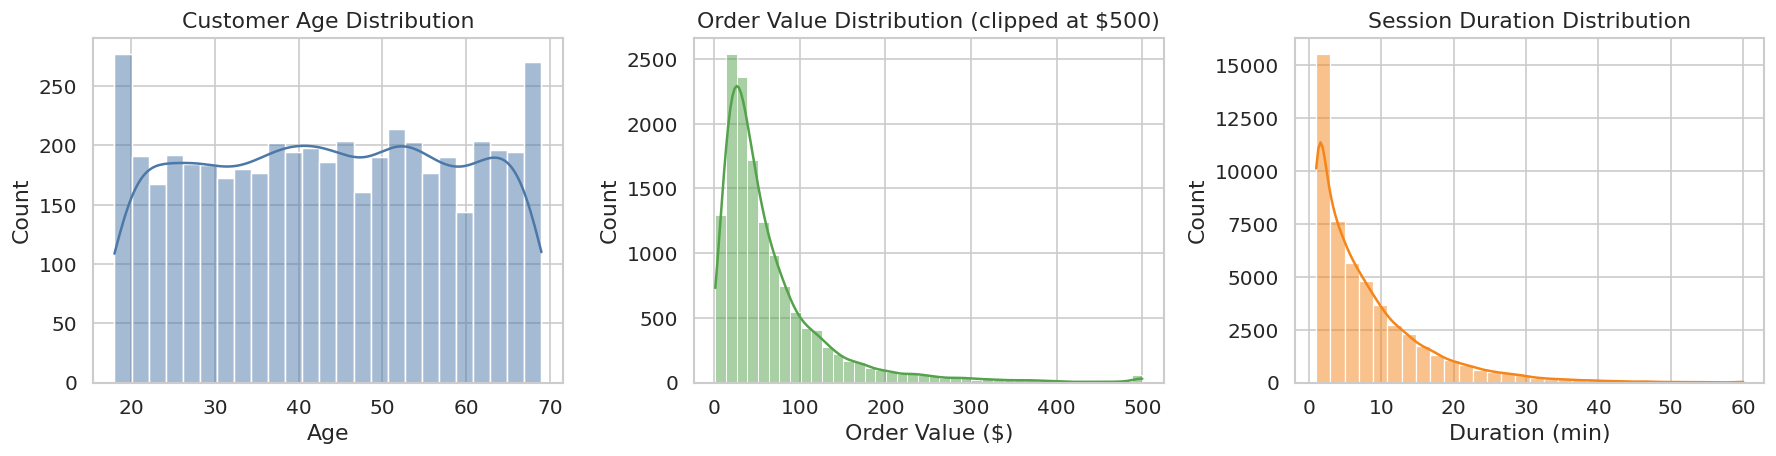

In [8]:
# Distribution Plots: age, order_value, session_duration
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(customers_df['age'].dropna(), bins=25, kde=True,
             color='#4c78a8', ax=axes[0])
axes[0].set_title('Customer Age Distribution')
axes[0].set_xlabel('Age')

sns.histplot(orders_df['order_value'].clip(upper=500), bins=40, kde=True,
             color='#54a24b', ax=axes[1])
axes[1].set_title('Order Value Distribution (clipped at $500)')
axes[1].set_xlabel('Order Value ($)')

sns.histplot(sessions_df['session_duration'], bins=30, kde=True,
             color='#f58518', ax=axes[2])
axes[2].set_title('Session Duration Distribution')
axes[2].set_xlabel('Duration (min)')

plt.tight_layout()
plt.show()

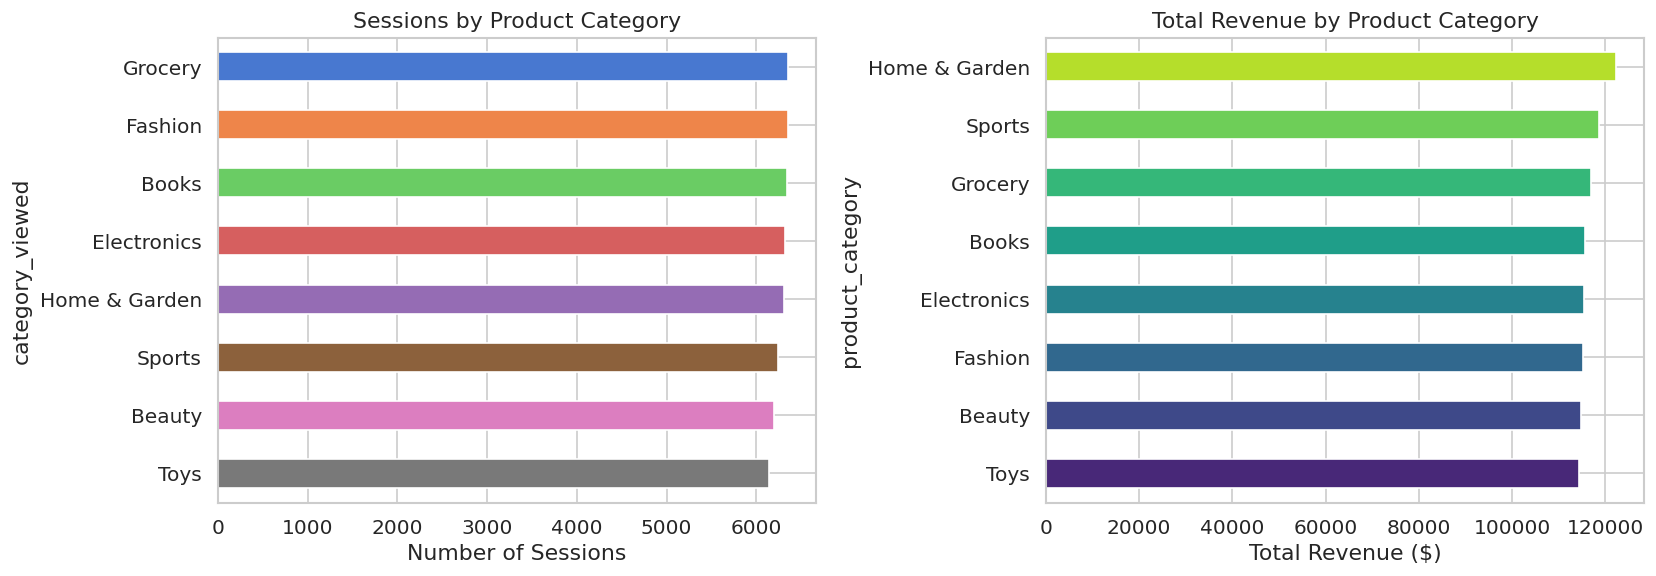

In [9]:
# Category Sessions and Revenue Breakdown
orders_df['order_date'] = pd.to_datetime(orders_df['order_date'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = sessions_df['category_viewed'].value_counts()
cat_counts.plot(kind='barh', ax=axes[0],
                color=sns.color_palette('muted', len(cat_counts)))
axes[0].set_title('Sessions by Product Category')
axes[0].set_xlabel('Number of Sessions')
axes[0].invert_yaxis()

rev_by_cat = orders_df.groupby('product_category')['order_value'].sum().sort_values(ascending=True)
rev_by_cat.plot(kind='barh', ax=axes[1],
                color=sns.color_palette('viridis', len(rev_by_cat)))
axes[1].set_title('Total Revenue by Product Category')
axes[1].set_xlabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

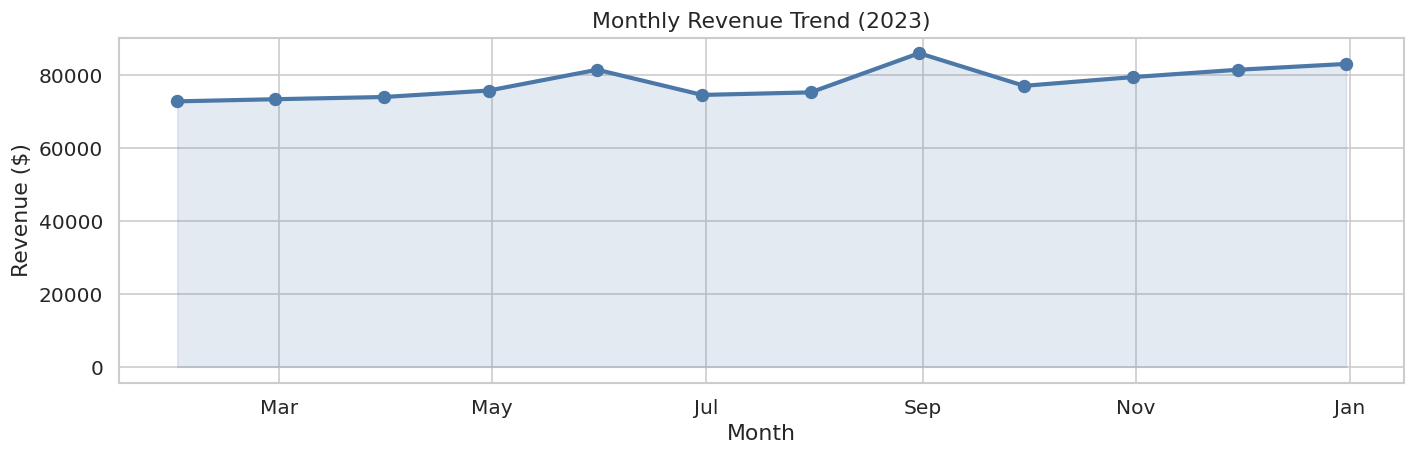

In [10]:
# Monthly Revenue Trend
monthly_rev = orders_df.resample('ME', on='order_date')['order_value'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_rev.index, monthly_rev.values, marker='o', linewidth=2.5,
        color='#4c78a8', markersize=7)
ax.fill_between(monthly_rev.index, monthly_rev.values, alpha=0.15, color='#4c78a8')
ax.set_title('Monthly Revenue Trend (2023)')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b'))
plt.tight_layout()
plt.show()

## 3. Data Cleaning

In [11]:
# Data Cleaning Pipeline
# Steps:
#   1. Remove duplicate session rows
#   2. Impute missing numeric values (median strategy)
#   3. Impute missing categorical values (mode strategy)
#   4. Clip extreme order values (cap at 99th percentile)
#   5. Validate referential integrity (sessions -> customers)

# Step 1: drop duplicates in sessions
before = len(sessions_df)
sessions_df = sessions_df.drop_duplicates(subset='session_id').reset_index(drop=True)
print(f'Step 1 – Removed {before - len(sessions_df)} duplicate session rows.')

# Step 2: impute numeric missing values with median
customers_df['age'].fillna(customers_df['age'].median(), inplace=True)
customers_df['loyalty_score'].fillna(customers_df['loyalty_score'].median(), inplace=True)
print('Step 2 – Imputed missing age & loyalty_score with median.')

# Step 3: impute missing categorical with mode
sessions_df['device'].fillna(sessions_df['device'].mode()[0], inplace=True)
print('Step 3 – Imputed missing device with mode.')

# Step 4: cap order value at 99th percentile to reduce outlier influence
p99 = orders_df['order_value'].quantile(0.99)
orders_df['order_value'] = orders_df['order_value'].clip(upper=p99)
print(f'Step 4 – Capped order_value at 99th pct (${p99:.2f}).')

# Step 5: drop sessions with customer_ids not in customers table
valid_ids = set(customers_df['customer_id'])
before = len(sessions_df)
sessions_df = sessions_df[sessions_df['customer_id'].isin(valid_ids)].reset_index(drop=True)
print(f'Step 5 – Dropped {before - len(sessions_df)} sessions with invalid customer IDs.')

print('\nNull check after cleaning:')
null_check = pd.concat(
    [customers_df.isnull().sum(), sessions_df.isnull().sum(), orders_df.isnull().sum()],
    axis=1, keys=['customers', 'sessions', 'orders']
)
print(null_check[null_check.sum(axis=1) > 0])

Step 1 – Removed 250 duplicate session rows.
Step 2 – Imputed missing age & loyalty_score with median.
Step 3 – Imputed missing device with mode.
Step 4 – Capped order_value at 99th pct ($365.63).
Step 5 – Dropped 0 sessions with invalid customer IDs.

Null check after cleaning:
Empty DataFrame
Columns: [customers, sessions, orders]
Index: []


## 4. Feature Engineering

In [12]:
# Session-Level Time Features
# Extract: hour_of_day, day_of_week, month, is_weekend from session_date

sessions_df['session_date'] = pd.to_datetime(sessions_df['session_date'])
sessions_df['hour_of_day']  = sessions_df['session_date'].dt.hour
sessions_df['day_of_week']  = sessions_df['session_date'].dt.dayofweek
sessions_df['month']        = sessions_df['session_date'].dt.month
sessions_df['is_weekend']   = (sessions_df['day_of_week'] >= 5).astype(int)

print('Time-based session features created:')
print(sessions_df[['session_date', 'hour_of_day', 'day_of_week', 'month', 'is_weekend']].head())

Time-based session features created:
         session_date  hour_of_day  day_of_week  month  is_weekend
0 2023-09-06 07:53:23            7            2      9           0
1 2023-02-13 05:40:50            5            0      2           0
2 2023-01-10 17:07:01           17            1      1           0
3 2023-10-15 23:45:05           23            6     10           1
4 2023-04-17 19:27:32           19            0      4           0


In [13]:
# Customer-Level Aggregate Features: RFM + Behavioural

# RFM (Recency, Frequency, Monetary) is the gold-standard for customer value.
# Additional features: avg_session_duration, avg_pages_per_session,
# preferred_device, preferred_category, cart_abandon_rate, return_rate

SNAPSHOT_DATE = pd.Timestamp('2024-01-01')

# RFM from orders
rfm = orders_df.groupby('customer_id').agg(
    last_order_date = ('order_date', 'max'),
    frequency       = ('order_id', 'count'),
    monetary        = ('order_value', 'sum'),
    avg_order_value = ('order_value', 'mean'),
    total_items     = ('items_purchased', 'sum'),
    return_rate     = ('return_flag', 'mean'),
    discount_rate   = ('discount_applied', 'mean'),
).reset_index()
rfm['recency_days'] = (SNAPSHOT_DATE - pd.to_datetime(rfm['last_order_date'])).dt.days
rfm.drop('last_order_date', axis=1, inplace=True)

# Session-level aggregates
sess_agg = sessions_df.groupby('customer_id').agg(
    total_sessions        = ('session_id', 'count'),
    avg_session_duration  = ('session_duration', 'mean'),
    avg_pages_per_session = ('pages_viewed', 'mean'),
    avg_cart_adds         = ('items_added_cart', 'mean'),
    conversion_rate       = ('converted', 'mean'),
    preferred_device      = ('device', lambda x: x.mode()[0]),
    preferred_category    = ('category_viewed', lambda x: x.mode()[0]),
    weekend_session_pct   = ('is_weekend', 'mean'),
    avg_hour              = ('hour_of_day', 'mean'),
).reset_index()

# Cart abandon rate: sessions with items added but no conversion
abandon = sessions_df.copy()
abandon['abandoned'] = ((abandon['items_added_cart'] > 0) & (abandon['converted'] == 0)).astype(int)
abandon_rate = abandon.groupby('customer_id')['abandoned'].mean().reset_index()
abandon_rate.rename(columns={'abandoned': 'cart_abandon_rate'}, inplace=True)
sess_agg = sess_agg.merge(abandon_rate, on='customer_id', how='left')

# Merge everything
customer_features = (
    customers_df
    .merge(rfm, on='customer_id', how='left')
    .merge(sess_agg, on='customer_id', how='left')
)

# Fill customers who never ordered
no_order_cols = ['frequency', 'monetary', 'avg_order_value', 'total_items',
                 'return_rate', 'discount_rate', 'recency_days']
customer_features[no_order_cols] = customer_features[no_order_cols].fillna(0)

# Churn Label: churned if no order in last 90 days OR never ordered
customer_features['churned'] = (
    (customer_features['recency_days'] > 90) | (customer_features['frequency'] == 0)
).astype(int)

print(f'Feature matrix shape: {customer_features.shape}')
print(f'Churn rate: {customer_features["churned"].mean():.1%}')
print('\nSample row (transposed):')
display(customer_features.head(1).T)

Feature matrix shape: (5000, 24)
Churn rate: 50.5%

Sample row (transposed):


,0
customer_id,C00001
age,56.0
gender,Female
region,West
membership_days,185
loyalty_score,67.0
frequency,2.0
monetary,147.46
avg_order_value,73.73
total_items,7.0


RFM_Segment
Potential Loyalists    1340
Loyal                  1179
Champions               911
At Risk                 814
Lost                    475
Name: count, dtype: int64


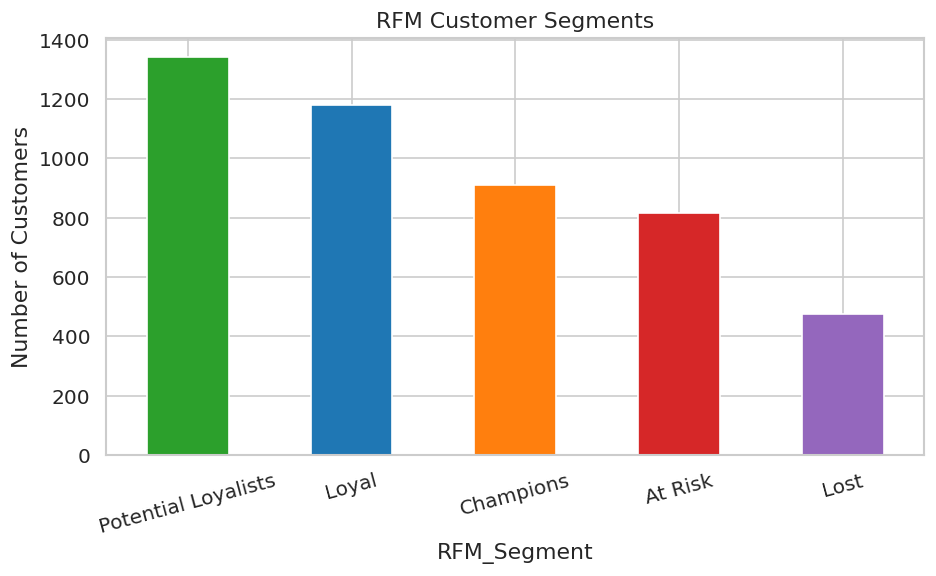

In [14]:
# RFM Segmentation (quintile scoring 1-5 on each dimension)

def rfm_score(df, col, ascending=True, q=5):
    labels = list(range(1, q + 1))
    if not ascending:
        labels = labels[::-1]
    return pd.qcut(df[col].rank(method='first'), q=q, labels=labels)

buying_customers = customer_features[customer_features['frequency'] > 0].copy()
buying_customers['R'] = rfm_score(buying_customers, 'recency_days', ascending=True)
buying_customers['F'] = rfm_score(buying_customers, 'frequency',    ascending=False)
buying_customers['M'] = rfm_score(buying_customers, 'monetary',     ascending=False)
buying_customers['RFM_Score'] = (
    buying_customers[['R', 'F', 'M']].astype(int).sum(axis=1)
)

def rfm_segment(score):
    if score >= 13: return 'Champions'
    if score >= 10: return 'Loyal'
    if score >= 7:  return 'Potential Loyalists'
    if score >= 5:  return 'At Risk'
    return 'Lost'

buying_customers['RFM_Segment'] = buying_customers['RFM_Score'].apply(rfm_segment)

seg_dist = buying_customers['RFM_Segment'].value_counts()
print(seg_dist)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd']
seg_dist.plot(kind='bar', ax=ax, color=colors, edgecolor='white', rot=15)
ax.set_title('RFM Customer Segments')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

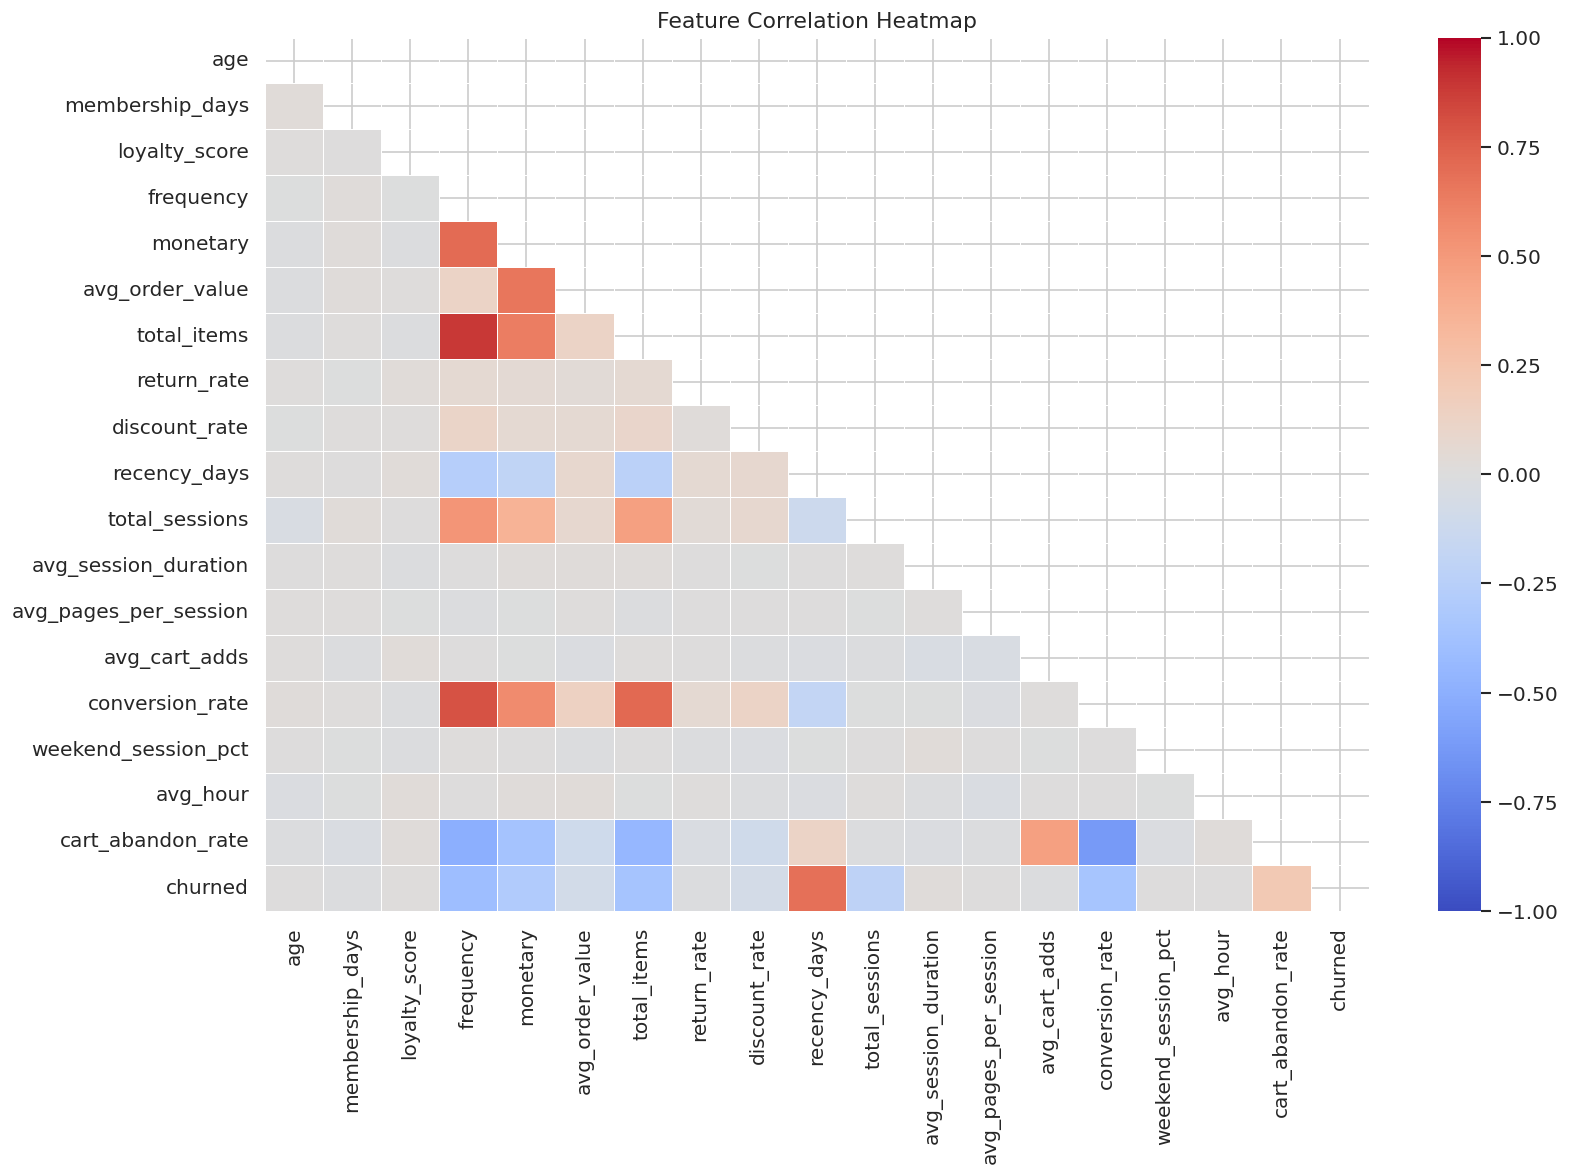

In [15]:
# Correlation Heatmap of Engineered Features
numeric_cols = customer_features.select_dtypes(include=np.number).columns.tolist()
corr_matrix  = customer_features[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 5. Apache Spark – Big Data Processing

### Why Apache Spark?
Apache Spark is a distributed in-memory computing framework built for large-scale data processing. Key advantages for this e-commerce use case:

| Concern | Spark's Solution |
|---|---|
| Dataset scale (millions of sessions/day) | Distributes across executor cores; processes data in parallel partitions |
| Complex aggregations (RFM, behaviour) | Catalyst query optimizer generates efficient physical execution plans |
| ML at scale | spark.ml integrates ML pipelines natively with distributed DataFrames |
| Fault tolerance | RDD lineage enables automatic re-computation on node failure |
| Ecosystem | Native connectors to Kafka, HDFS, Amazon S3, Apache Cassandra |

In production, the sessions table alone may contain **billions of rows per day**. Pandas would exhaust memory; Spark distributes the work horizontally.

In [16]:
# Initialise SparkSession
spark = (
    SparkSession.builder
    .appName('EcommerceCustomerAnalysis')
    .master('local[*]')                          # use all available CPU cores
    .config('spark.sql.shuffle.partitions', '8') # tuned for local mode
    .config('spark.driver.memory', '2g')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')  # suppress verbose INFO logs
print(f'Spark version : {spark.version}')
print(f'Spark UI      : http://localhost:4040')

Spark version : 4.0.2
Spark UI      : http://localhost:4040


In [17]:
# Load Pandas DataFrames into Spark
sp_sessions  = spark.createDataFrame(sessions_df.astype(str))
sp_orders    = spark.createDataFrame(orders_df.astype({
    'order_value': 'float',
    'items_purchased': 'int',
    'discount_applied': 'int',
    'return_flag': 'int'
}))
sp_customers = spark.createDataFrame(customers_df)

# Register as SQL views for ad-hoc querying
sp_sessions.createOrReplaceTempView('sessions')
sp_orders.createOrReplaceTempView('orders')
sp_customers.createOrReplaceTempView('customers')

print(f'Sessions  in Spark : {sp_sessions.count():,}')
print(f'Orders    in Spark : {sp_orders.count():,}')
print(f'Customers in Spark : {sp_customers.count():,}')

Sessions  in Spark : 50,000
Orders    in Spark : 13,970
Customers in Spark : 5,000


In [18]:
# Spark SQL: Revenue & Return Rates by Product Category
revenue_sql = """
    SELECT
        product_category,
        COUNT(order_id)                     AS num_orders,
        ROUND(SUM(order_value), 2)          AS total_revenue,
        ROUND(AVG(order_value), 2)          AS avg_order_value,
        ROUND(AVG(discount_applied)*100, 1) AS discount_pct,
        ROUND(AVG(return_flag)*100, 1)      AS return_pct
    FROM orders
    GROUP BY product_category
    ORDER BY total_revenue DESC
"""
spark.sql(revenue_sql).show(truncate=False)

+----------------+----------+-------------+---------------+------------+----------+
|product_category|num_orders|total_revenue|avg_order_value|discount_pct|return_pct|
+----------------+----------+-------------+---------------+------------+----------+
|Home & Garden   |1741      |117681.37    |67.59          |41.1        |11.3      |
|Sports          |1705      |114908.27    |67.39          |39.6        |12.2      |
|Books           |1782      |114834.8     |64.44          |38.4        |10.5      |
|Grocery         |1777      |114351.76    |64.35          |38.7        |11.1      |
|Fashion         |1742      |113694.54    |65.27          |40.0        |11.9      |
|Beauty          |1771      |112560.39    |63.56          |42.4        |12.1      |
|Toys            |1720      |112525.54    |65.42          |41.0        |12.8      |
|Electronics     |1732      |112009.33    |64.67          |41.1        |12.6      |
+----------------+----------+-------------+---------------+------------+----

In [19]:
# Spark DataFrame API: Customer RFM Aggregation
# Demonstrates how Spark computes RFM efficiently on a large orders table.

sp_orders_typed = sp_orders.withColumn('order_date', F.to_timestamp('order_date'))
snapshot = F.lit('2024-01-01').cast('timestamp')

spark_rfm = (
    sp_orders_typed
    .groupBy('customer_id')
    .agg(
        F.datediff(snapshot, F.max('order_date')).alias('recency_days'),
        F.count('order_id').alias('frequency'),
        F.round(F.sum('order_value'), 2).alias('monetary'),
        F.round(F.avg('order_value'), 2).alias('avg_order_value'),
        F.round(F.avg('return_flag') * 100, 1).alias('return_rate_pct'),
    )
)

print('Spark RFM (top 10 by revenue):')
spark_rfm.orderBy(F.desc('monetary')).show(10, truncate=False)

Spark RFM (top 10 by revenue):
+-----------+------------+---------+--------+---------------+---------------+
|customer_id|recency_days|frequency|monetary|avg_order_value|return_rate_pct|
+-----------+------------+---------+--------+---------------+---------------+
|C00159     |13          |9        |1398.87 |155.43         |11.1           |
|C00027     |122         |5        |1110.96 |222.19         |40.0           |
|C01107     |57          |8        |931.8   |116.48         |12.5           |
|C02769     |79          |6        |897.11  |149.52         |16.7           |
|C01132     |168         |4        |883.42  |220.86         |25.0           |
|C01858     |150         |7        |872.73  |124.68         |0.0            |
|C03417     |4           |4        |871.25  |217.81         |50.0           |
|C00896     |15          |8        |865.36  |108.17         |37.5           |
|C00575     |20          |6        |853.91  |142.32         |16.7           |
|C01321     |61          |5      

In [20]:
# Spark Window Functions: Rank Customers within Each Category

cust_cat_rev = (
    sp_orders_typed
    .groupBy('customer_id', 'product_category')
    .agg(F.round(F.sum('order_value'), 2).alias('cat_revenue'))
)

window_spec = Window.partitionBy('product_category').orderBy(F.desc('cat_revenue'))

ranked = (
    cust_cat_rev
    .withColumn('rank_in_category', F.rank().over(window_spec))
    .filter(F.col('rank_in_category') <= 3)
    .orderBy('product_category', 'rank_in_category')
)
print('Top 3 customers by revenue per product category:')
ranked.show(30, truncate=False)

Top 3 customers by revenue per product category:
+-----------+----------------+-----------+----------------+
|customer_id|product_category|cat_revenue|rank_in_category|
+-----------+----------------+-----------+----------------+
|C01685     |Beauty          |496.09     |1               |
|C01886     |Beauty          |443.23     |2               |
|C02538     |Beauty          |441.3      |3               |
|C01440     |Books           |453.45     |1               |
|C01858     |Books           |405.04     |2               |
|C02525     |Books           |368.02     |3               |
|C03212     |Electronics     |558.29     |1               |
|C00159     |Electronics     |546.79     |2               |
|C01222     |Electronics     |453.0      |3               |
|C03365     |Fashion         |550.05     |1               |
|C03097     |Fashion         |478.16     |2               |
|C01779     |Fashion         |462.92     |3               |
|C01132     |Grocery         |731.25     |1        

Spark ML RandomForest AUC-ROC on test set: 0.9988


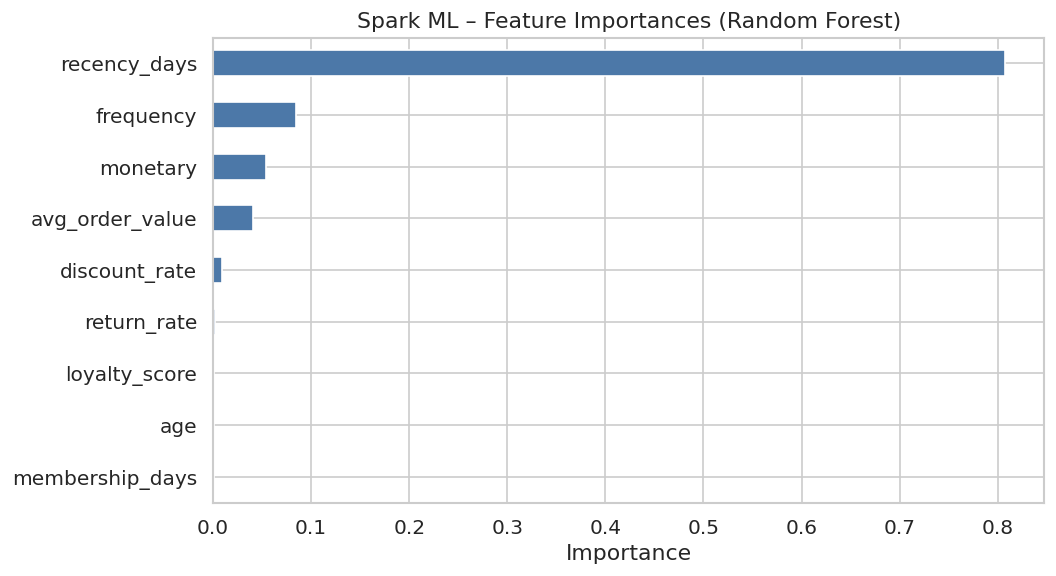

In [21]:
# Spark ML Pipeline: Churn Prediction with Random Forest
# This pipeline runs entirely within Spark's distributed ML framework.

SPARK_FEATURES = [
    'age', 'membership_days', 'loyalty_score',
    'frequency', 'monetary', 'recency_days', 'avg_order_value',
    'return_rate', 'discount_rate'
]

spark_model_df = spark.createDataFrame(
    customer_features[SPARK_FEATURES + ['churned']].fillna(0)
)

for c in SPARK_FEATURES:
    spark_model_df = spark_model_df.withColumn(c, F.col(c).cast('double'))
spark_model_df = spark_model_df.withColumnRenamed('churned', 'label')

train_sp, test_sp = spark_model_df.randomSplit([0.8, 0.2], seed=SEED)

assembler  = VectorAssembler(inputCols=SPARK_FEATURES, outputCol='features_raw')
scaler     = SparkScaler(inputCol='features_raw', outputCol='features')
rf_spark   = SparkRF(numTrees=100, maxDepth=5, seed=SEED,
                     featuresCol='features', labelCol='label')

spark_pipeline = SparkPipeline(stages=[assembler, scaler, rf_spark])
spark_model    = spark_pipeline.fit(train_sp)

predictions  = spark_model.transform(test_sp)
evaluator    = BinaryClassificationEvaluator(rawPredictionCol='rawPrediction',
                                              metricName='areaUnderROC')
auc = evaluator.evaluate(predictions)
print(f'Spark ML RandomForest AUC-ROC on test set: {auc:.4f}')

# Feature importances
importances = spark_model.stages[-1].featureImportances.toArray()
spark_fi = pd.Series(importances, index=SPARK_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
spark_fi.plot(kind='barh', ax=ax, color='#4c78a8', edgecolor='white')
ax.set_title('Spark ML – Feature Importances (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 6. Predictive Modeling – Customer Churn

In [22]:
# Prepare Sklearn Feature Matrix (full set of engineered features)

le = LabelEncoder()
model_df = customer_features.copy()
for col in ['gender', 'region', 'preferred_device', 'preferred_category']:
    model_df[col] = model_df[col].fillna('Unknown')
    model_df[col] = le.fit_transform(model_df[col].astype(str))

FEATURE_COLS = [
    # Demographics
    'age', 'gender', 'region', 'membership_days', 'loyalty_score',
    # RFM
    'recency_days', 'frequency', 'monetary', 'avg_order_value',
    'total_items', 'return_rate', 'discount_rate',
    # Behaviour
    'total_sessions', 'avg_session_duration', 'avg_pages_per_session',
    'avg_cart_adds', 'conversion_rate', 'preferred_device',
    'preferred_category', 'weekend_session_pct', 'cart_abandon_rate',
]

X = model_df[FEATURE_COLS].fillna(0).values
y = model_df['churned'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f'Train : {len(X_train):,} samples | Churn rate: {y_train.mean():.1%}')
print(f'Test  : {len(X_test):,}  samples | Churn rate: {y_test.mean():.1%}')

Train : 4,000 samples | Churn rate: 50.5%
Test  : 1,000  samples | Churn rate: 50.5%


In [26]:
# --- OPTIMIZATION: REMOVE LEAKAGE & FIND BEST MODEL ---

# 1. Identify and remove features that directly define the 'churned' target
# 'recency_days', 'frequency', and 'monetary' are direct math rules for churn.
LEAKAGE_COLS = ['recency_days', 'frequency', 'monetary', 'avg_order_value', 'total_items']
VALID_FEATURES = [col for col in FEATURE_COLS if col not in LEAKAGE_COLS]

# 2. Re-prepare the training and test sets using ONLY valid behavioral features
X = model_df[VALID_FEATURES].fillna(0).values
y = model_df['churned'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# 3. Define Models
models = {
    'Logistic Regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('clf',     LogisticRegression(max_iter=500, random_state=SEED))
    ]),
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf',     RandomForestClassifier(n_estimators=200, max_depth=8,
                                            random_state=SEED, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf',     GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                               learning_rate=0.05,
                                               random_state=SEED))
    ]),
}

# 4. Evaluation Loop
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

print(f"{'Model':25s} | {'Test AUC':8s} | {'CV AUC (Stability)':15s}")
print("-" * 65)

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    # Calculate scores
    test_auc = roc_auc_score(y_test, y_proba)
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    results[name] = {
        'auc': test_auc,
        'cv_mean': cv_scores.mean()
    }

    print(f'{name:25s} | {test_auc:.4f}   | {cv_scores.mean():.4f} (+/- {cv_scores.std():.2f})')

# 5. Print the Best Model Summary
best_model_name = max(results, key=lambda k: results[k]['auc'])
print("\n" + "="*40)
print(f"WINNING MODEL: {best_model_name}")
print(f"FINAL TEST AUC: {results[best_model_name]['auc']:.4f}")
print("="*40)

Model                     | Test AUC | CV AUC (Stability)
-----------------------------------------------------------------
Logistic Regression       | 0.7303   | 0.7271 (+/- 0.02)
Random Forest             | 0.7248   | 0.7204 (+/- 0.02)
Gradient Boosting         | 0.7077   | 0.7104 (+/- 0.02)

WINNING MODEL: Logistic Regression
FINAL TEST AUC: 0.7303



Logistic Regression:
              precision    recall  f1-score   support

    Retained       0.67      0.67      0.67       495
     Churned       0.68      0.67      0.67       505

    accuracy                           0.67      1000
   macro avg       0.67      0.67      0.67      1000
weighted avg       0.67      0.67      0.67      1000


Random Forest:
              precision    recall  f1-score   support

    Retained       0.66      0.69      0.67       495
     Churned       0.68      0.65      0.66       505

    accuracy                           0.67      1000
   macro avg       0.67      0.67      0.67      1000
weighted avg       0.67      0.67      0.67      1000


Gradient Boosting:
              precision    recall  f1-score   support

    Retained       0.64      0.65      0.65       495
     Churned       0.65      0.64      0.65       505

    accuracy                           0.65      1000
   macro avg       0.65      0.65      0.65      1000
weighted avg    

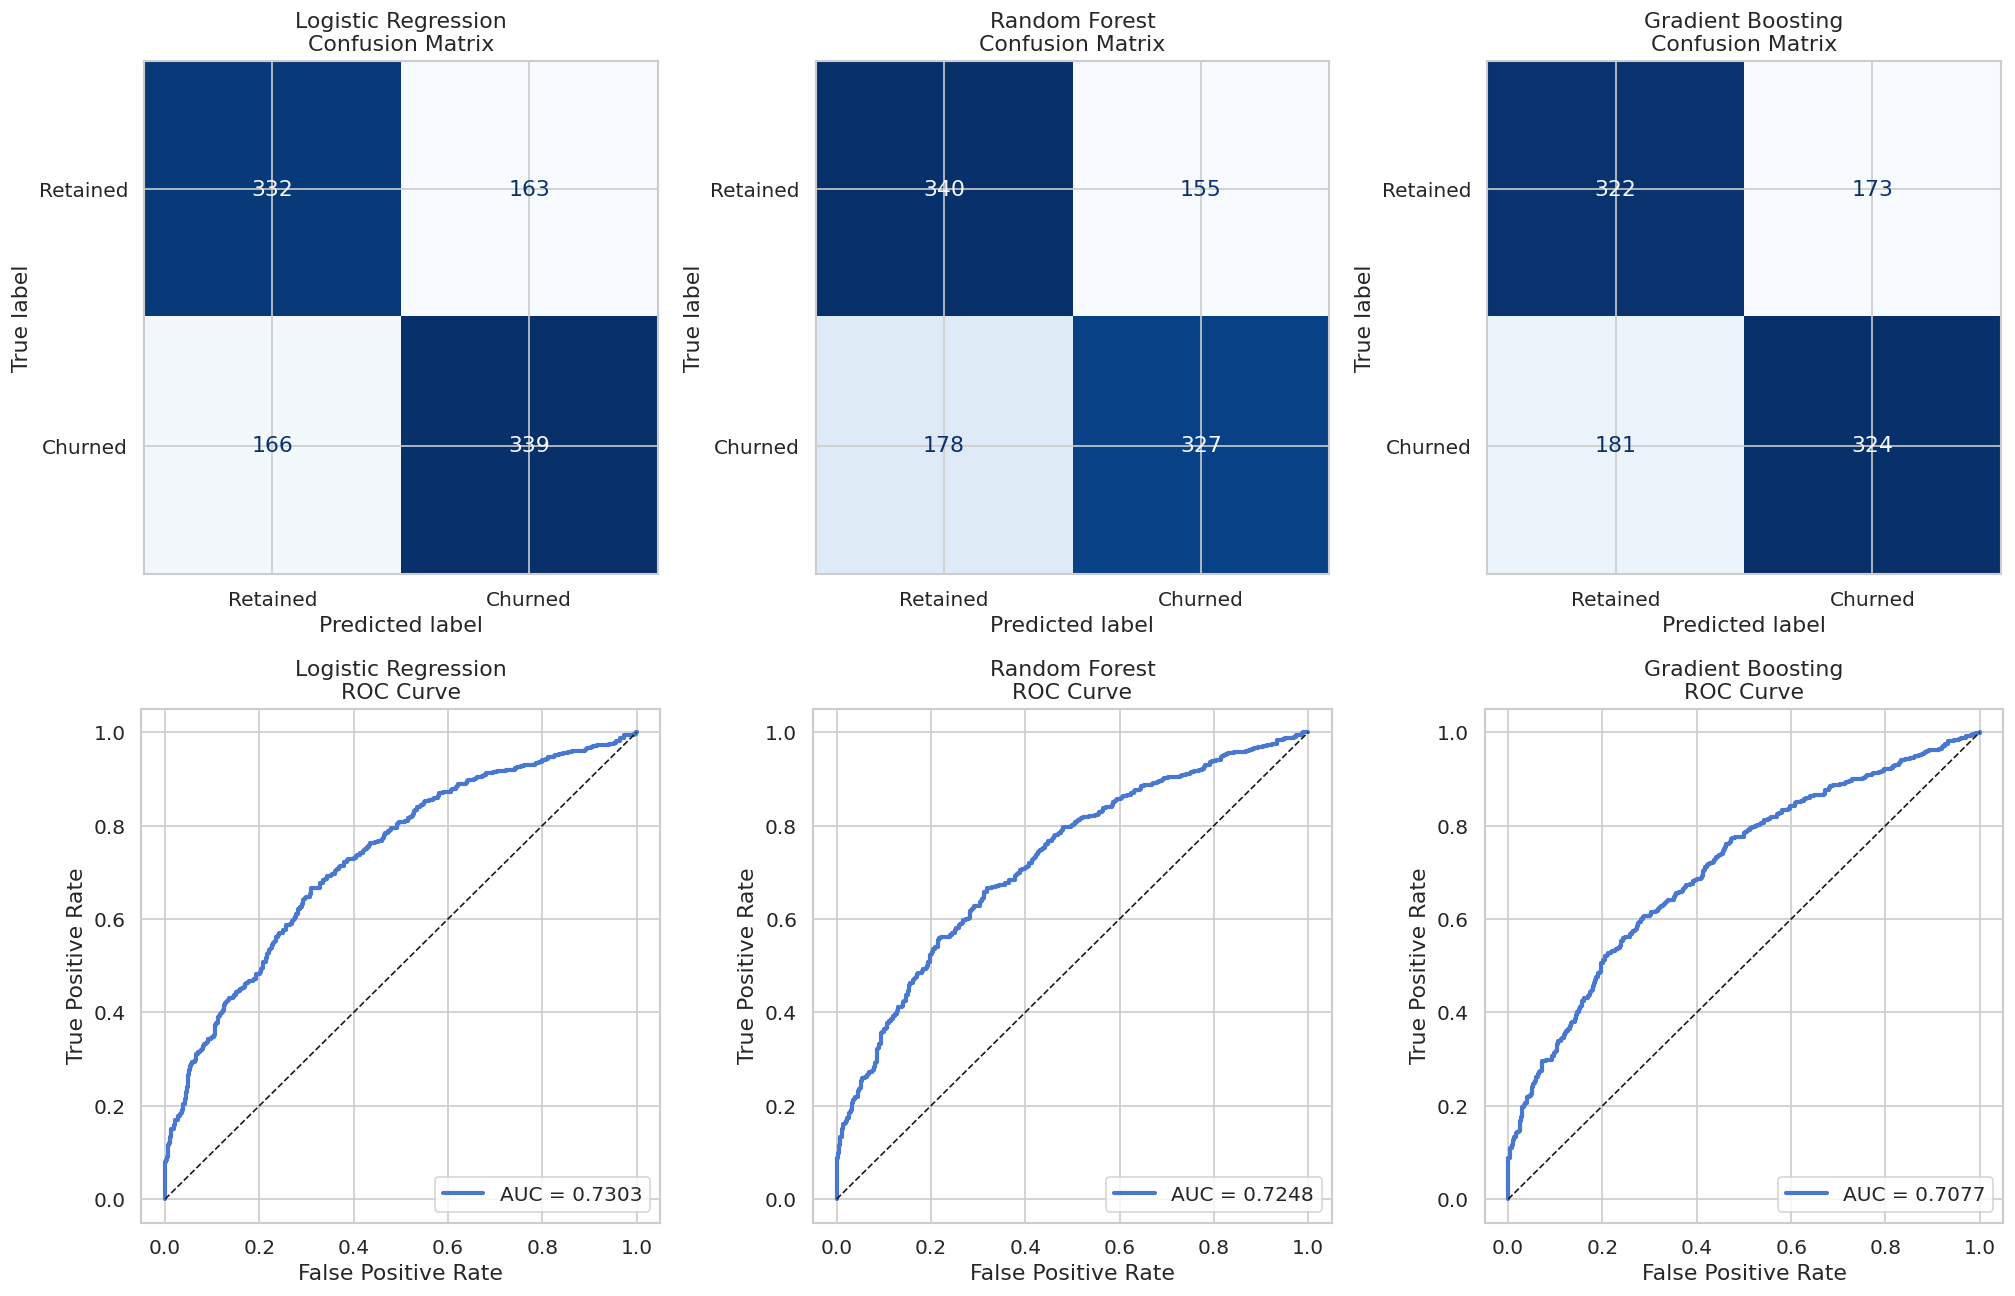

In [28]:
import numpy as np

# Re-calculate y_pred and y_proba for each model and store in results dictionary
# The models dictionary, X_test, and y_test are available from previous cells' execution.
# The 'results' dictionary already contains 'auc' and 'cv_mean' for each model.
for name, pipe in models.items():
    # Get predictions and probabilities
    y_proba_model = pipe.predict_proba(X_test)[:, 1]
    y_pred_model = pipe.predict(X_test)

    # Store them in the results dictionary
    results[name]['y_proba'] = y_proba_model
    results[name]['y_pred'] = y_pred_model

fig, axes = plt.subplots(2, 3, figsize=(17, 11))

for idx, (name, res) in enumerate(results.items()):
    # Confusion matrix
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned']).plot(
        ax=axes[0, idx], colorbar=False, cmap='Blues')
    axes[0, idx].set_title(f'{name}\nConfusion Matrix')

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[1, idx].plot(fpr, tpr, linewidth=2.5, label=f'AUC = {res["auc"]:.4f}')
    axes[1, idx].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[1, idx].set_title(f'{name}\nROC Curve')
    axes[1, idx].set_xlabel('False Positive Rate')
    axes[1, idx].set_ylabel('True Positive Rate')
    axes[1, idx].legend(loc='lower right')

    print(f'\n{name}:')
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['Retained', 'Churned']))

plt.tight_layout()
plt.show()

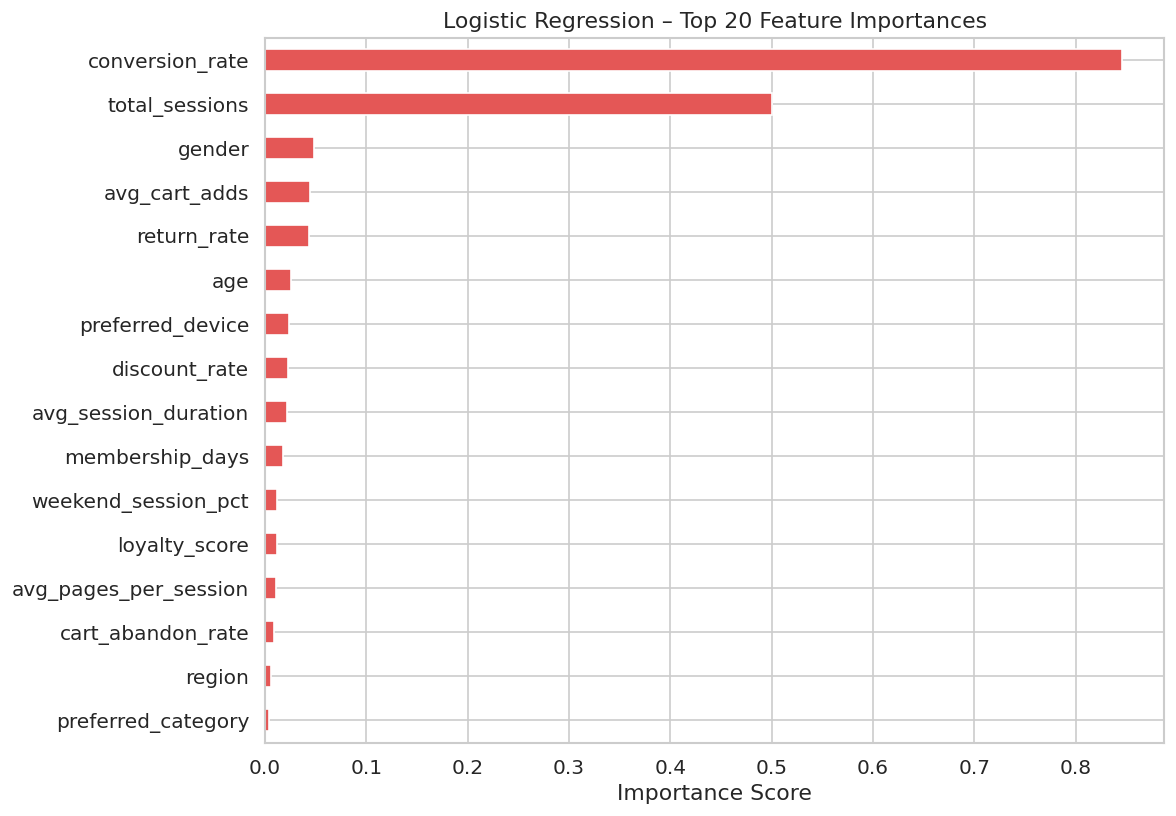

Top 10 most predictive features for churn:
conversion_rate         0.845537
total_sessions          0.500596
gender                  0.048471
avg_cart_adds           0.044734
return_rate             0.043604
age                     0.025574
preferred_device        0.023916
discount_rate           0.022219
avg_session_duration    0.021430
membership_days         0.017658
dtype: float64


In [32]:
# Best Model: Feature Importances (Top 20)

best_pipe = models[best_model_name]
clf = best_pipe.named_steps['clf']

# Dynamically get feature importances based on classifier type
if hasattr(clf, 'feature_importances_'):
    feature_importance_values = clf.feature_importances_
elif hasattr(clf, 'coef_'):
    # For linear models like Logistic Regression, use absolute coefficients
    feature_importance_values = np.abs(clf.coef_[0])
else:
    # Fallback or error if neither is available
    feature_importance_values = np.zeros(len(VALID_FEATURES))

fi = pd.Series(feature_importance_values, index=VALID_FEATURES).sort_values(ascending=True)
top20 = fi.tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.plot(kind='barh', ax=ax, color='#e45756', edgecolor='white')
ax.set_title(f'{best_model_name} – Top 20 Feature Importances')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 10 most predictive features for churn:')
print(top20.tail(10).sort_values(ascending=False))

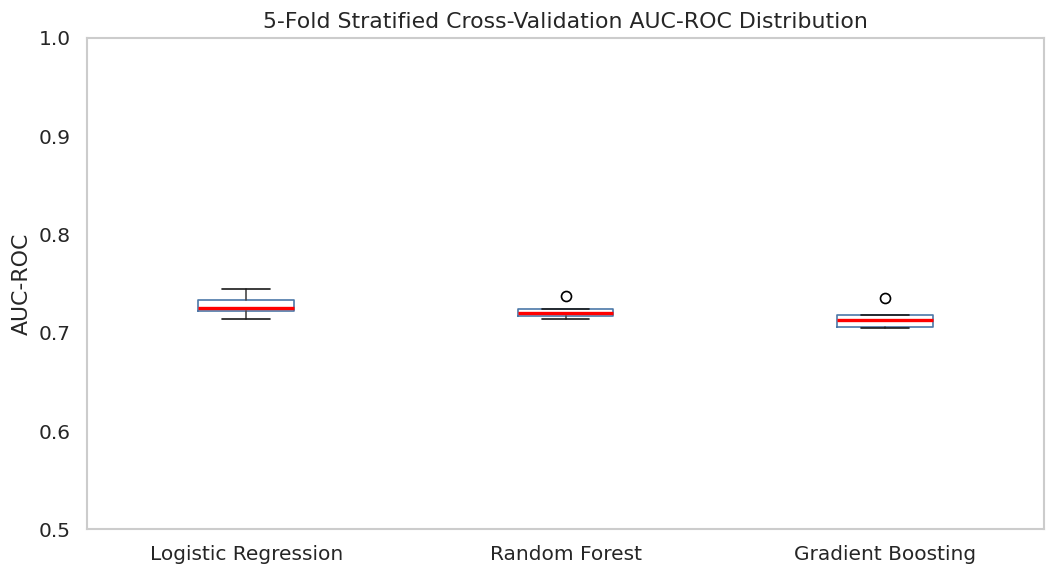

Logistic Regression      : 0.7276 +/- 0.0107
Random Forest            : 0.7224 +/- 0.0080
Gradient Boosting        : 0.7153 +/- 0.0111


In [34]:
# Cross-Validation Score Distribution

cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores

cv_df = pd.DataFrame(cv_results)

fig, ax = plt.subplots(figsize=(9, 5))
cv_df.boxplot(ax=ax, grid=False,
              boxprops=dict(color='#4c78a8'),
              medianprops=dict(color='red', linewidth=2))
ax.set_title('5-Fold Stratified Cross-Validation AUC-ROC Distribution')
ax.set_ylabel('AUC-ROC')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

for name, scores in cv_results.items():
    print(f'{name:25s}: {scores.mean():.4f} +/- {scores.std():.4f}')

## 7. Insights and Visualizations

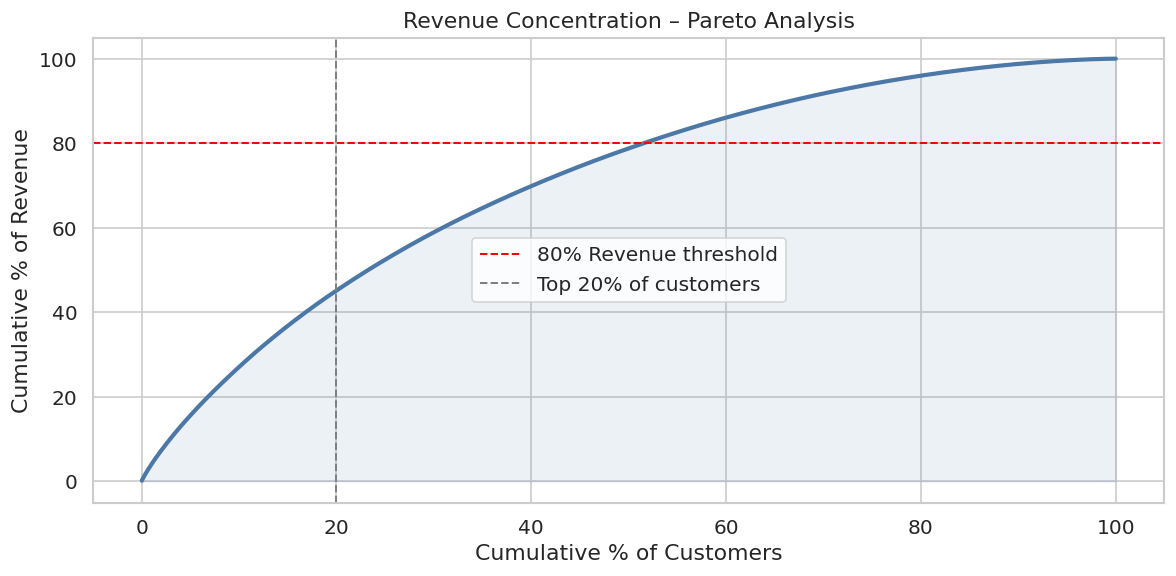

Top 20% of customers generate 45.1% of revenue


In [35]:
# Revenue Concentration – Pareto (80/20) Analysis

cust_revenue = (
    orders_df.groupby('customer_id')['order_value'].sum()
    .sort_values(ascending=False)
    .reset_index()
)
cust_revenue['cum_pct_revenue']   = cust_revenue['order_value'].cumsum() / cust_revenue['order_value'].sum() * 100
cust_revenue['cum_pct_customers'] = np.arange(1, len(cust_revenue)+1) / len(cust_revenue) * 100

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cust_revenue['cum_pct_customers'], cust_revenue['cum_pct_revenue'],
        linewidth=2.5, color='#4c78a8')
ax.axhline(80, color='red',  linestyle='--', linewidth=1.2, label='80% Revenue threshold')
ax.axvline(20, color='grey', linestyle='--', linewidth=1.2, label='Top 20% of customers')
ax.fill_between(cust_revenue['cum_pct_customers'],
                cust_revenue['cum_pct_revenue'], alpha=0.1, color='#4c78a8')
ax.set_xlabel('Cumulative % of Customers')
ax.set_ylabel('Cumulative % of Revenue')
ax.set_title('Revenue Concentration – Pareto Analysis')
ax.legend()
plt.tight_layout()
plt.show()

p20_idx = (cust_revenue['cum_pct_customers'] - 20).abs().idxmin()
print(f"Top 20% of customers generate "
      f"{cust_revenue.loc[p20_idx,'cum_pct_revenue']:.1f}% of revenue")

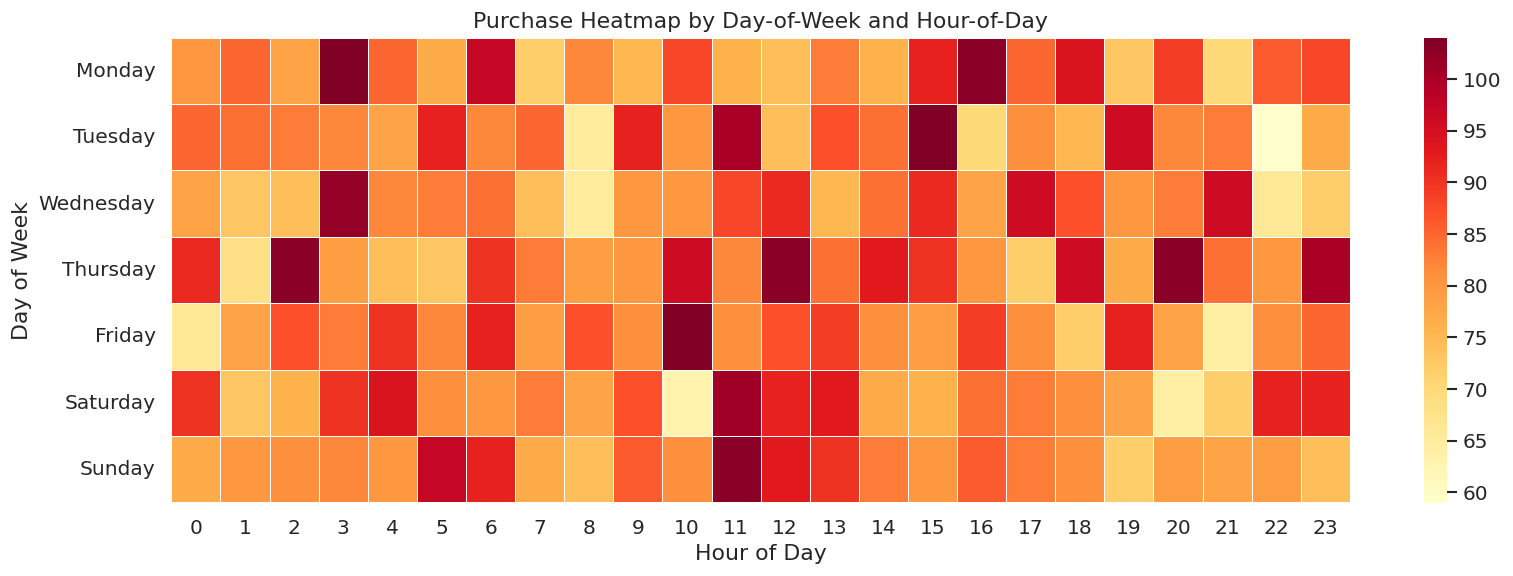

In [36]:
# Hour-of-Day and Day-of-Week Purchase Heatmap

heatmap_data = (
    sessions_df[sessions_df['converted'] == 1]
    .assign(hour=lambda d: d['session_date'].dt.hour,
            dow =lambda d: d['session_date'].dt.day_name())
    .groupby(['dow', 'hour'])['converted']
    .count()
    .unstack(fill_value=0)
)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heatmap_data = heatmap_data.reindex(day_order)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', linewidths=0.3, ax=ax)
ax.set_title('Purchase Heatmap by Day-of-Week and Hour-of-Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()

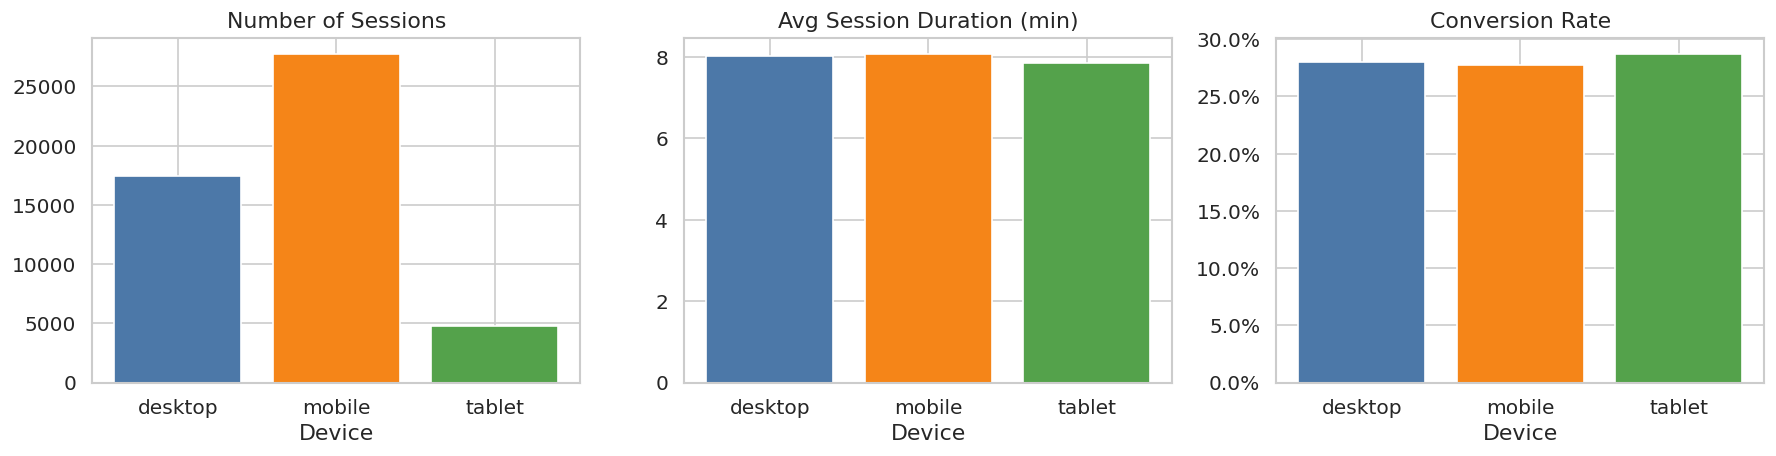

 device  sessions  avg_duration  avg_pages  conversion_rate
desktop     17480      8.033982  15.064474         0.280149
 mobile     27746      8.073946  14.950696         0.277590
 tablet      4774      7.855404  15.037076         0.287181


In [37]:
# Device-Level Session Metrics

device_metrics = (
    sessions_df.groupby('device')
    .agg(
        sessions        = ('session_id', 'count'),
        avg_duration    = ('session_duration', 'mean'),
        avg_pages       = ('pages_viewed', 'mean'),
        conversion_rate = ('converted', 'mean'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metric_pairs = [
    ('sessions',        'Number of Sessions'),
    ('avg_duration',    'Avg Session Duration (min)'),
    ('conversion_rate', 'Conversion Rate'),
]
bar_colors = ['#4c78a8', '#f58518', '#54a24b']
for ax, (col, label) in zip(axes, metric_pairs):
    ax.bar(device_metrics['device'], device_metrics[col], color=bar_colors)
    ax.set_title(label)
    ax.set_xlabel('Device')
    if col == 'conversion_rate':
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()
print(device_metrics.to_string(index=False))

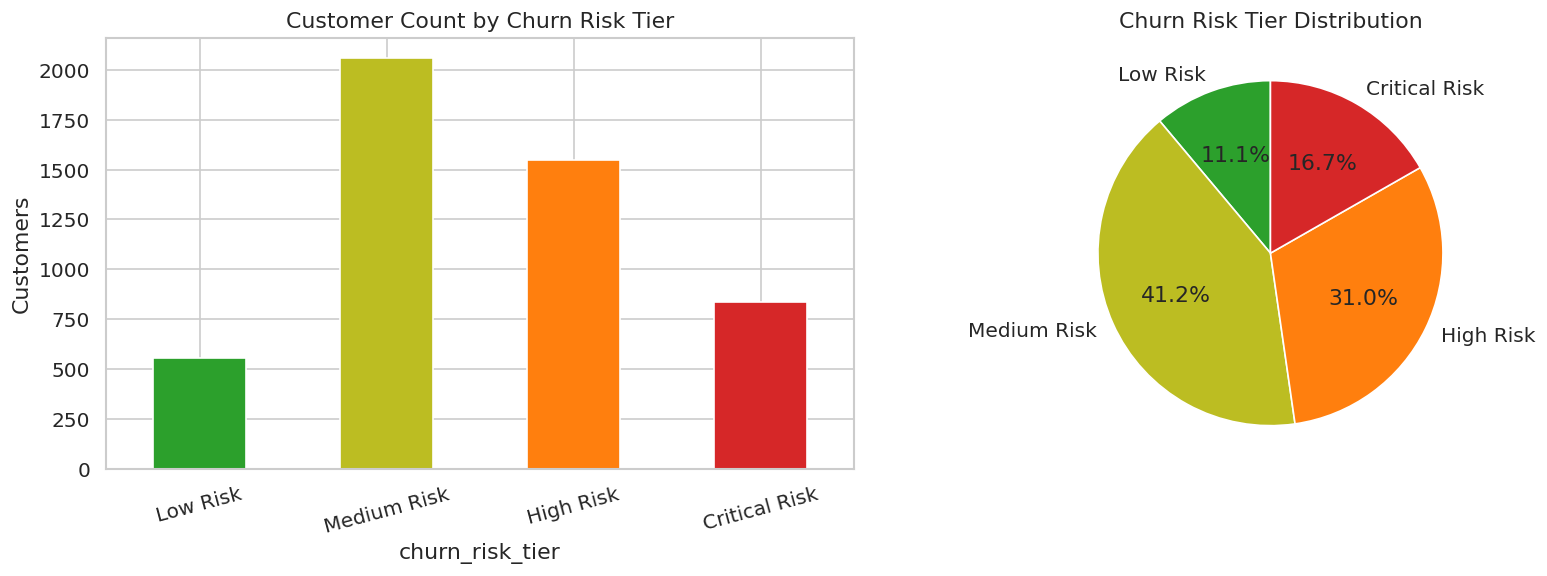


Average churn probability per tier:
churn_risk_tier
Low Risk         0.181067
Medium Risk      0.386091
High Risk        0.620573
Critical Risk    0.813465
Name: churn_probability, dtype: float64


In [39]:
# Churn Risk Tiering and Distribution

model_df['churn_probability'] = best_pipe.predict_proba(
    model_df[VALID_FEATURES].fillna(0).values
)[:, 1]

bins   = [0, 0.25, 0.50, 0.75, 1.0]
labels = ['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
model_df['churn_risk_tier'] = pd.cut(model_df['churn_probability'],
                                      bins=bins, labels=labels)

tier_dist = model_df['churn_risk_tier'].value_counts().sort_index()
tier_pct  = tier_dist / len(model_df) * 100
colors_tier = ['#2ca02c', '#bcbd22', '#ff7f0e', '#d62728']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tier_dist.plot(kind='bar', ax=axes[0], color=colors_tier, edgecolor='white', rot=15)
axes[0].set_title('Customer Count by Churn Risk Tier')
axes[0].set_ylabel('Customers')

axes[1].pie(tier_pct, labels=tier_pct.index, autopct='%1.1f%%',
            colors=colors_tier, startangle=90,
            wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Churn Risk Tier Distribution')

plt.tight_layout()
plt.show()

print('\nAverage churn probability per tier:')
print(model_df.groupby('churn_risk_tier')['churn_probability'].mean())

In [40]:
# Cleanup: Stop Spark Session
spark.stop()
print('SparkSession stopped. Analysis complete.')

SparkSession stopped. Analysis complete.


In [41]:
import matplotlib.pyplot as plt
import os

# Create a folder to store the images
output_dir = 'visualizations'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print(f"Saving images to the '{output_dir}' directory...")

# 1. Missing Values and Duplicates Audit
# (Assuming 'customers_df', 'sessions_df', and 'orders_df' are defined)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (df, title) in zip(axes, [(customers_df, 'Customers'), (sessions_df, 'Sessions'), (orders_df, 'Orders')]):
    miss = df.isnull().mean() * 100
    if not miss[miss > 0].empty:
        miss[miss > 0].plot(kind='bar', ax=ax, color='#e07b54', edgecolor='white')
    else:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(f'{title} – Missing Values')
plt.tight_layout()
plt.savefig(f'{output_dir}/01_missing_values.jpg', format='jpg', dpi=300)
plt.close()

# 2. Distribution Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(customers_df['age'].dropna(), bins=25, kde=True, color='#4c78a8', ax=axes[0])
sns.histplot(orders_df['order_value'].clip(upper=500), bins=40, kde=True, color='#54a24b', ax=axes[1])
sns.histplot(sessions_df['session_duration'], bins=30, kde=True, color='#f58518', ax=axes[2])
plt.tight_layout()
plt.savefig(f'{output_dir}/02_distributions.jpg', format='jpg', dpi=300)
plt.close()

# 3. Category Sessions and Revenue
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sessions_df['category_viewed'].value_counts().plot(kind='barh', ax=axes[0])
orders_df.groupby('product_category')['order_value'].sum().sort_values().plot(kind='barh', ax=axes[1])
plt.tight_layout()
plt.savefig(f'{output_dir}/03_category_analysis.jpg', format='jpg', dpi=300)
plt.close()

# 4. Monthly Revenue Trend
monthly_rev = orders_df.resample('ME', on='order_date')['order_value'].sum()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_rev.index, monthly_rev.values, marker='o', color='#4c78a8')
plt.savefig(f'{output_dir}/04_monthly_revenue.jpg', format='jpg', dpi=300)
plt.close()

# 5. RFM Segments
fig, ax = plt.subplots(figsize=(8, 5))
buying_customers['RFM_Segment'].value_counts().plot(kind='bar', ax=ax, color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728', '#9467bd'])
plt.savefig(f'{output_dir}/05_rfm_segments.jpg', format='jpg', dpi=300)
plt.close()

# 6. Feature Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(customer_features.select_dtypes(include=np.number).corr(), cmap='coolwarm', annot=False)
plt.savefig(f'{output_dir}/06_correlation_heatmap.jpg', format='jpg', dpi=300)
plt.close()

# 7. Model Performance (Confusion Matrices and ROC Curves)
# Note: Re-runs the loop for the results dict
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned']).plot(ax=axes[0, idx], colorbar=False, cmap='Blues')
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    axes[1, idx].plot(fpr, tpr, label=f'AUC = {res["auc"]:.4f}')
plt.tight_layout()
plt.savefig(f'{output_dir}/07_model_performance.jpg', format='jpg', dpi=300)
plt.close()

# 8. Pareto Analysis (80/20 Rule)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cust_revenue['cum_pct_customers'], cust_revenue['cum_pct_revenue'], color='#4c78a8')
ax.axhline(80, color='red', linestyle='--')
plt.savefig(f'{output_dir}/08_pareto_analysis.jpg', format='jpg', dpi=300)
plt.close()

# 9. Churn Risk Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_df['churn_risk_tier'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#2ca02c', '#bcbd22', '#ff7f0e', '#d62728'])
model_df['churn_risk_tier'].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%', startangle=90)
plt.tight_layout()
plt.savefig(f'{output_dir}/09_churn_risk_tiers.jpg', format='jpg', dpi=300)
plt.close()

print("All plots have been saved successfully in the 'visualizations' folder.")

Saving images to the 'visualizations' directory...
All plots have been saved successfully in the 'visualizations' folder.
